# GLMs in RStan I
# Poisson and Zero-Inflated Poisson Regression

This article is part of a series:

- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/GLMs%20in%20RStan%20I%20-%20Poisson%20and%20ZIP%20Regression.ipynb">GLMs in RStan I - Poisson and ZIP Regression</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/GLMs%20in%20RStan%20II%20-%20Negative%20Binomial%20and%20ZINB%20Regression.ipynb">GLMs in RStan II - Negative Binomial and ZINB Regression</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/GLMs%20in%20RStan%20III%20-%20Gamma%20Regression.ipynb">GLMs in RStan III - Gamma Regression</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/GLMs%20in%20RStan%20IV%20-%20GLMs%20in%20RStan%20Summary.ipynb">GLMs in RStan IV - Summary</a>

You may also be interested in <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20VII%20-%20Bayesian%20Modeling%20in%20RStan.ipynb">Bayesian Inference VII - Bayesian Modeling in RStan</a>.

# Outline

<ul>
    <li>Generalized Linear Models (GLMs)</li>
    </br>
    <li>Poisson Regression</li>
    </br>
    <li>Poisson Regression Implementation</li>
        <ul>
            <li>Cloth Defects Dataset</li>
        </ul>
    </br>
    <li>Zero-Inflated Poisson (ZIP) Regression</li>
        <ul>
            <li>Zero-Inflated Cloth Defects Dataset</li>
        </ul>
    </br>
    <li>Doing it With Priors</li>
        <ul>
            <li>Bootstrapped Normal Priors for Roll Length</li>
            <li>Bootstrapped Intercept and Slope Priors for Num Flaws</li>
            <li>Regular Poisson Regression with Priors</li>
            <li>Bootstrapping ZIP Regression Parameters</li>
            <li>ZIP Regression with Priors</li>
        </ul>

# Generalized Linear Models (GLMs)

A generalized linear model allows the use of custom distributions for the likelihood. We write
$Y \sim \phi(f(\mu), \theta)$, where $\phi$ is an arbitrary distribution, and $\theta$ represents auxiliary parameters, such as $\sigma$ for the normal distribution. $f$ is called the inverse link function, and is the identity function when $\phi$ is normal (so we don't really worry about it), but when using a distribution constrained to positive values, we typically use a log-link function to connect the linear predictor of the mean to the response variable, while ensuring that the constraint is met.

# Poisson Regression

The Poisson distribution models count data, where the mean is assumed to be (approximately) equal to the variance.

- $P(Y=y|\lambda) = \frac{\lambda^y e^{-\lambda}}{y!}$

A log-link function models the relationship between the predictors and $\lambda$, which means:

- $log(\lambda) = \alpha + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_p x_p$

- $\lambda = e^{\alpha + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_p x_p}$

Therefore, the coefficients represent the log change in the expected count for a one-unit change in the corresponding predictor.

- $\beta_j = log \left( \frac{\lambda(x+1)}{\lambda(x)} \right)$

- $e^{\beta_j} = \frac{\lambda(x+1)}{\lambda(x)}$

In [ ]:
# install.packages("BiocManager")
# library("BiocManager")

# BiocManager::install("rstan")
# BiocManager::install("GGally")
# BiocManager::install("boot")
# BiocManager::install("pscl")

library(rstan)
library(GGally) # for pair plots
library(boot) # for cloth dataset and bootstrapping
library(pscl) # for bootstrapping zip parameter

# Poisson Regression Implementation

## Cloth Defects Dataset

The following dataset is from the <code>boot</code> package, which we'll also utilize for bootstrapping priors later on. The <code>y</code> variable, which I'll rename <code>num_flaws</code>, indicates the number of holes found in various lengths of cloths during manufacturing. The lengths (and I am unsure of the unit of measurement) are indicated by the <code>x</code> variable, which I will rename <code>roll_length</code>. The roll length values are continuous, whereas the number of holes per cloth are discrete counts.

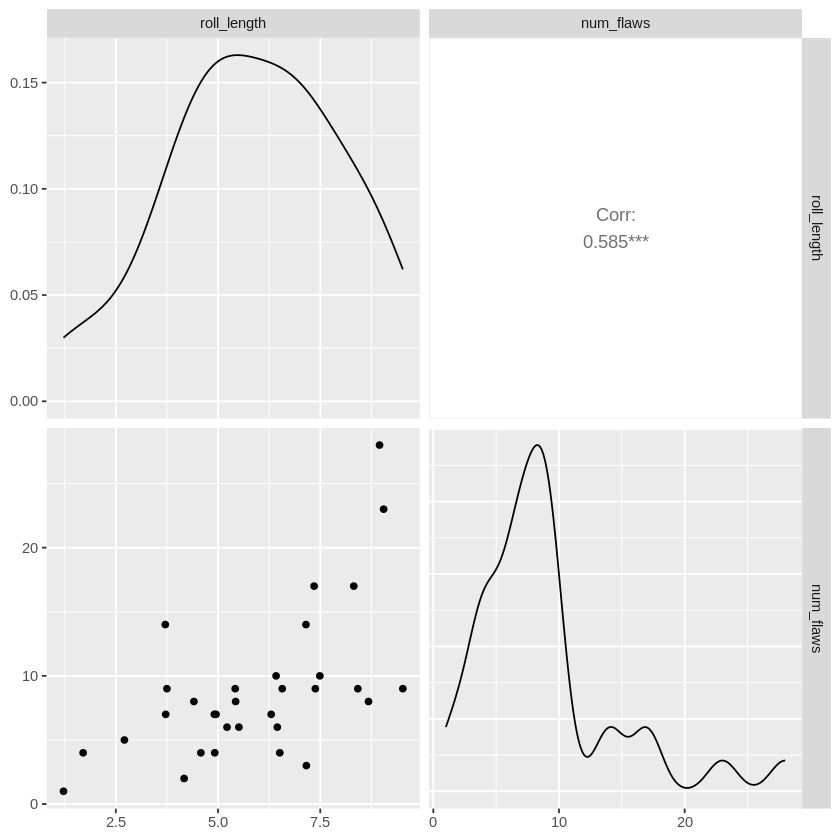

In [2]:
data <- cloth
names(data)[names(data) == "x"] <- "roll_length"
names(data)[names(data) == "y"] <- "num_flaws"

ggpairs(data)

To keep it simple, we'll not set any priors explicitly, allowing <code>stan</code> to assign flat ones. The <code>data{}</code> block is pretty simple, we set up an <code>x</code> variable and <code>y</code> variable to receive the data we pass in. In the <code>parameters{}</code> block, we declare the parameters of a normal distribution for <code>x</code>, and the <code>alpha</code> and <code>beta</code> parameters for $log(\lambda) = \alpha + \beta x$. <code>lambda</code> gets declared as an N-dimensional vector in the <code>model{}</code> block. In the <code>generated quantities</code> block, we generate two <code>N</code>-size vectors: <code>x_pred</code>, constrained to be positive, and <code>y_pred</code>, the Poisson-distributed linear function of <code>y_pred</code>. <code>lambda_pred</code> is an intermediary quantity by which the noise is distributed, and through which the <code>alpha</code> and <code>beta</code> regression parameters make their contribution.

In [4]:
stan_code <- "

  data {
      int<lower=0> N;
      vector[N] x;
      int<lower=0> y[N];
  }

  parameters {
      real x_mu, x_sigma;
      real alpha, beta;
  }

  model {
      vector[N] lambda;

      x ~ normal(x_mu, x_sigma);
      lambda = exp(alpha + beta * x);
      y ~ poisson(lambda);
  }

  generated quantities{
      vector[N] x_pred;
      vector[N] y_pred;

      for (n in 1:N) {
          x_pred[n] = fabs(normal_rng(x_mu, x_sigma));
          real lambda_pred = exp(x_pred[n] * beta + alpha);
          y_pred[n] = poisson_rng(lambda_pred);
      }
  }
  "

With that, we'll run the model,

In [5]:
x <- data$roll_length
y <- data$num_flaws

N <- length(x)
data_list <- list(N = N, x = x, y = y)
model_fit <- stan(model_code = stan_code, data = data_list, warmup = 1000,
                 iter = 2000, chains = 3, refresh = 0, cores = 8)

Run some diagnostic checks:

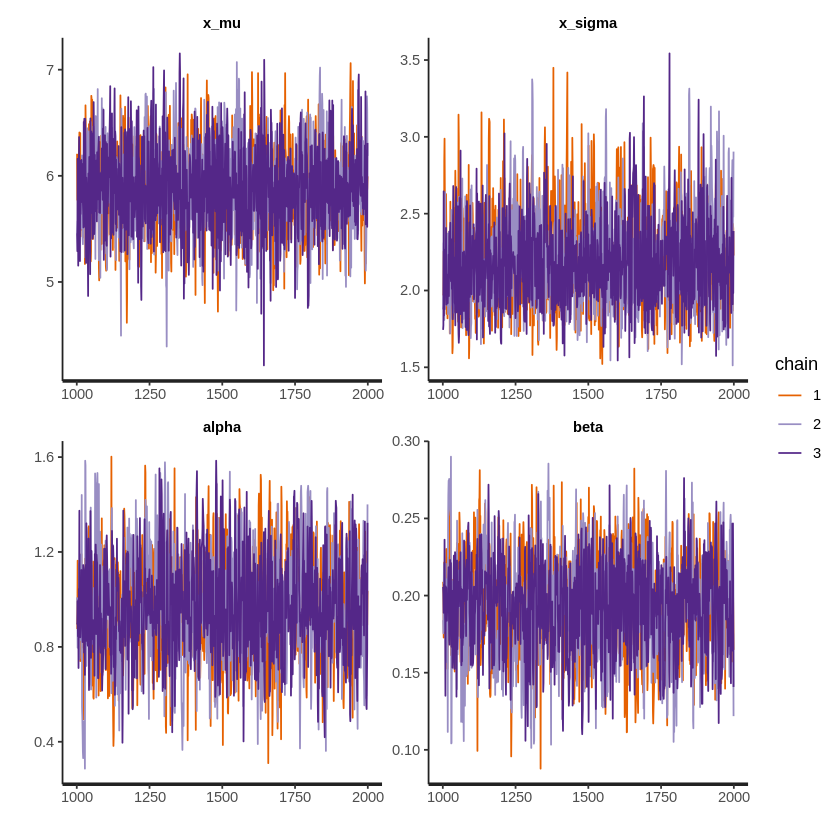

In [7]:
traceplot(model_fit, pars = c('x_mu', 'x_sigma', 'alpha', 'beta'))

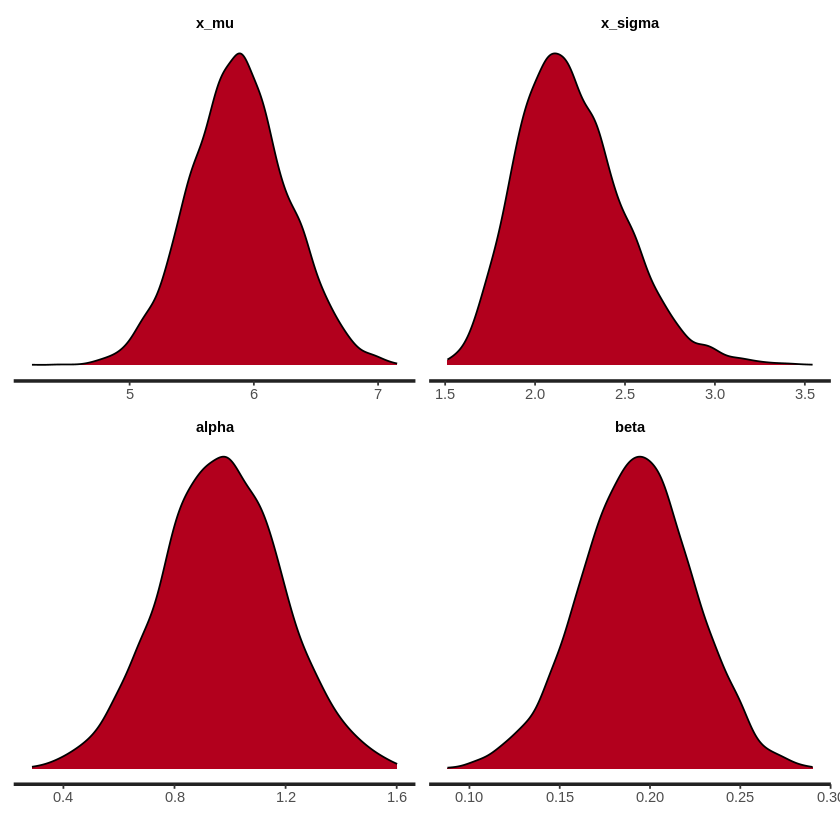

In [10]:
stan_dens(model_fit, pars = c('x_mu', 'x_sigma', 'alpha', 'beta'))

Extract the samples,

In [11]:
posterior_samples <- rstan::extract(model_fit)

And compare the generated quantities defining our model to the observed data. First separately,

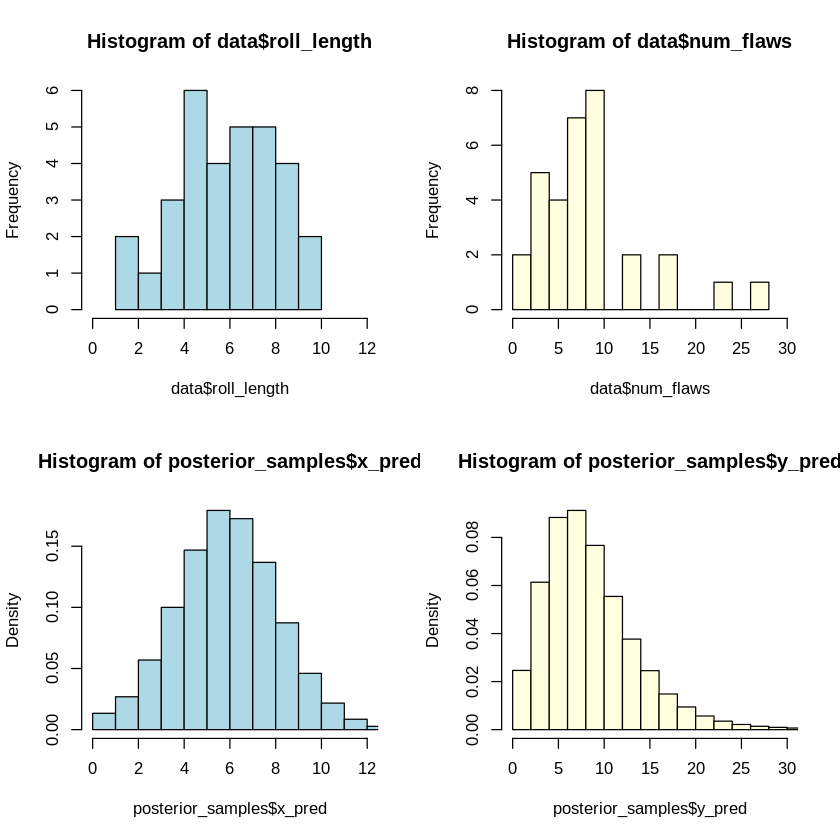

In [12]:
par(mfrow=c(2,2))
hist(data$roll_length, breaks=10, col="lightblue", xlim=c(0,12))
hist(data$num_flaws, breaks=12, col="lightyellow", xlim=c(0,30))
hist(posterior_samples$x_pred, breaks=20, col="lightblue", probability = TRUE, xlim=c(0,12))
hist(posterior_samples$y_pred, breaks=45, col="lightyellow", probability = TRUE, xlim=c(0,30))

and then in joint fashion.

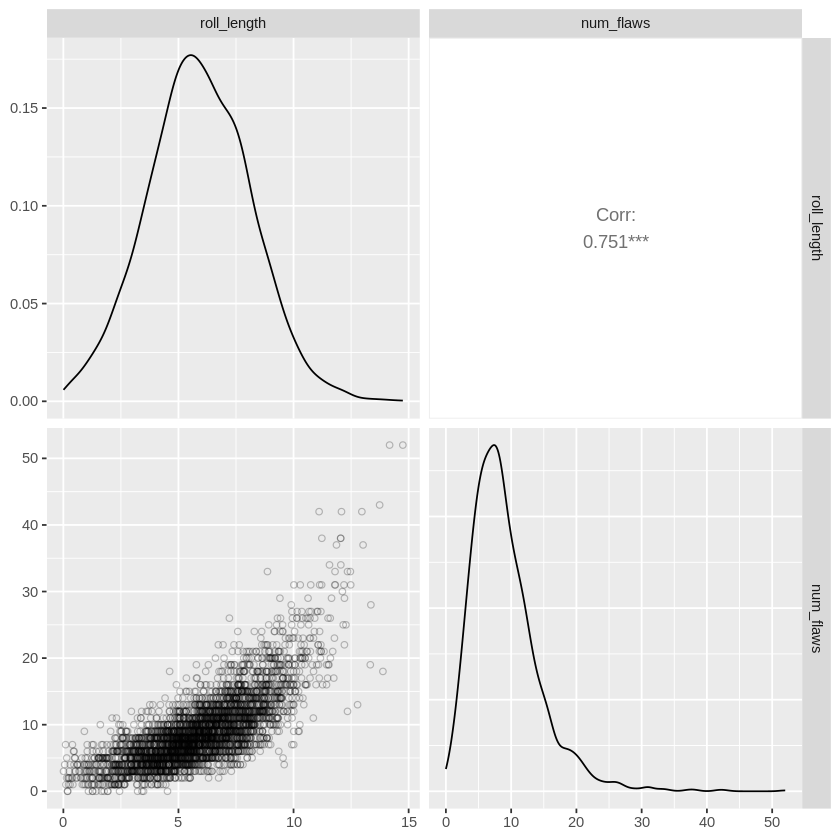

In [13]:
pred_df <- data.frame(roll_length = as.vector(posterior_samples$x_pred),
                      num_flaws = as.vector(posterior_samples$y_pred))
sampled_df <- pred_df[sample(1:nrow(pred_df), size = 4000), ]
ggpairs(sampled_df,
        lower = list(continuous = wrap("points", alpha = 0.25, shape = 1)),)

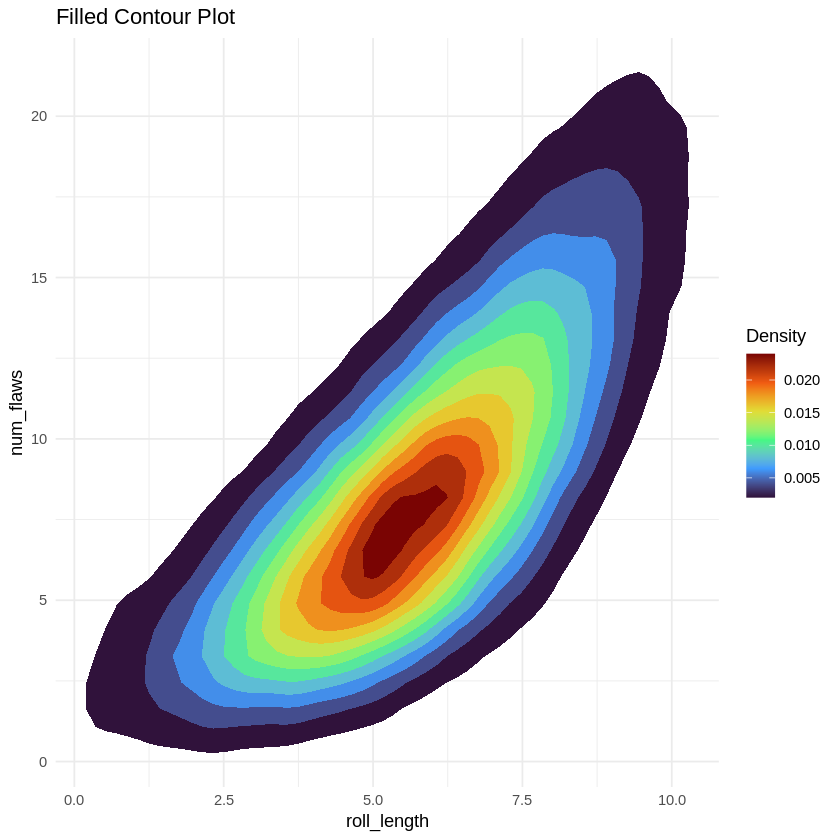

In [15]:
ggplot(pred_df, aes(x = roll_length, y = num_flaws)) +
  stat_density_2d(aes(fill = after_stat(level)), geom = "polygon") +
  scale_fill_viridis_c(option = "turbo") +
  theme_minimal() +
  labs(title = "Filled Contour Plot",
       x = "roll_length", y = "num_flaws", fill = "Density")

# Zero-Inflated Poisson (ZIP) Regression

It is not uncommon to have data in which the count of zeros makes for a poor fit to a Poisson model. Rather than create a separate model for the count of zeros, which would undesirably detach that data from the Poisson component, we can define a zero-inflated PMF, in which a zero is predicted with probability $\pi$, and a prediction from the Poisson distribution is used with probability $1-\pi$.

- $P(X=k)  =
\begin{cases}
  0, ~~~~~~~~~~~~~~~~\text{with probability } \pi  \\
  Pois(\lambda_i), ~~~~\text{with probability } 1-\pi \\
\end{cases}$

The mean and variance are:

- $E(X) = \lambda(1-\pi)$
- $Var(X) = \lambda(1-\pi)(1 + \lambda \pi)$

When $\pi=0$, the zero-inflated Poisson reduces to the Poisson.

## Zero-Inflated Cloth Defects Dataset

In a Python-focused article on the same subject, I utilized this <a href="https://stats.idre.ucla.edu/stat/data/fish.csv">campground fishing</a> dataset. For this, I will simply take our cloth dataset and inflate it with zeros, imagining that many of the cloths produced are defect-free. Rather than simulate a relationship between the zeros and the x-variable, I will keep it simple, and allow the selection of x-values (to accompany the zeros in the y variable) to be modeled by the entire distribution of the existing data.

In [16]:
new_x_vals <- abs(round(rnorm(20, mean=mean(data$roll_length), sd=sd(data$roll_length)), 2))
new_y_vals <- seq(0,0,length.out=20)
df <- data.frame(roll_length = new_x_vals, num_flaws = new_y_vals)
zero_inf_data <- rbind(data, df)

The <code>data{}</code> and <code>parameters{}</code> blocks of our <code>stan</code> code are the same except for the addition of a new parameter <code>pi</code>, bounded between 0 and 1.

The model block has gotten significantly more complicated, with regard to modeling the y-variable. If you don't yet understand it, it will make sense once a few <code>stan</code> functions are explained. Allow me to explain them in the following order:

- <code>target</code> is a built-in variable which <code>stan</code> uses to track and manage the log-probabilities while sampling. We wouldn't need to know about it unless using a custom-distribution such as our zero-inflation Poisson, as it gets initialized and handled automatically. All our inference method needs to know while sampling is an assessment of the log-probabilities of the samples, so the optimization of parameters is handled simply by us ensuring this information is provided.

- <code>log_mix</code> is a function used to compute the logarithm of a weighted mixture of the densities. You can see 3 components are embedded as arguments:

  - <code>pi</code> is the mixing proportion that determines the probability of drawing a zero from the zero-inflated component.

  - The value of the second argument, 0, represents the log-probability of generating zero from the zero-inflated component. $log(1)=0$, and the probability of a zero from the zero-generating component is 1, so we pass a 0.

  - <code>poisson_lpmf(0|exp(alpha + beta * x[n])</code> represents the log-probability of drawing a zero from the Poisson component.

  So within our <code>if</code> statement, if the $n^{th}$ instance of <code>y</code> equals 0, the log-probability of the result is either 0 or the log-probability of a zero from our fitted Poisson, depending on the value of the mixing parameter <code>pi</code>. If <code>y[n]</code> is not equal to zero, we multiply $(1-\pi)$ by the Poisson likelihood, and since taking the log-probability, we add instead of multiply. <code>log1m</code> is just a numerically stable version of 1 minus the value of the parameter in brackets.

In [17]:
stan_code <- "

data {
  int<lower=0> N;
  vector[N] x;
  int<lower=0> y[N];
}

parameters {
  real x_mu, x_sigma;
  real alpha, beta;
  real<lower=0, upper=1> pi;
}

model {

  x ~ normal(x_mu, x_sigma);

  for (n in 1:N) {
    if (y[n] == 0) {
      target += log_mix(pi,
                        0,                                                  // Log prob of y=0 in zero-inflated part
                        poisson_lpmf(0 | exp(alpha + beta * x[n])));        // Log-prob of y=0 in Poisson part
    } else {

      target += log1m(pi) + poisson_lpmf(y[n] | exp(alpha + beta * x[n]));  // Log-prob of data in Poisson part
    }
  }
}

generated quantities {
  vector[N] x_pred;
  int y_pred[N];

  for (n in 1:N) {
    x_pred[n] = fabs(normal_rng(x_mu, x_sigma));
    real lambda_pred = exp(alpha + beta * x_pred[n]);

    if (bernoulli_rng(pi) == 1) {
      y_pred[n] = 0;                         // zero from zero-inflation
    } else {
      y_pred[n] = poisson_rng(lambda_pred);  // Poisson generated value
    }
  }
}
"

In [18]:
x <- zero_inf_data$roll_length
y <- zero_inf_data$num_flaws

N <- length(x)
data_list <- list(N = N, x = x, y = y)
model_fit <- stan(model_code = stan_code, data = data_list, warmup=1000,
                 iter = 2000, chains = 3, refresh = 0, cores = 8)

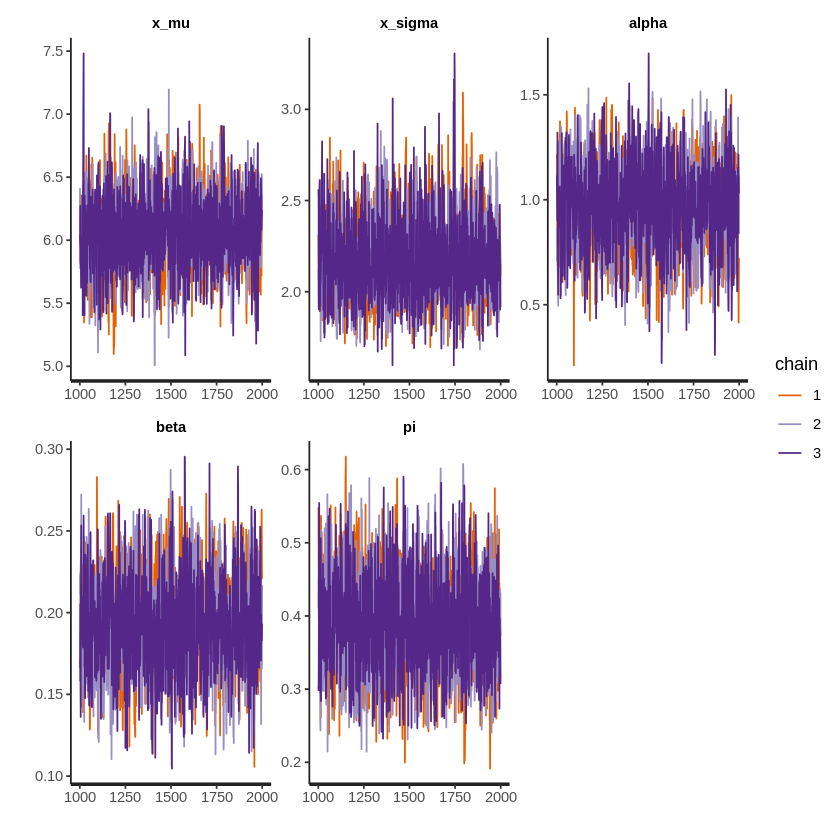

In [20]:
traceplot(model_fit, pars = c('x_mu', 'x_sigma', 'alpha', 'beta', 'pi'))

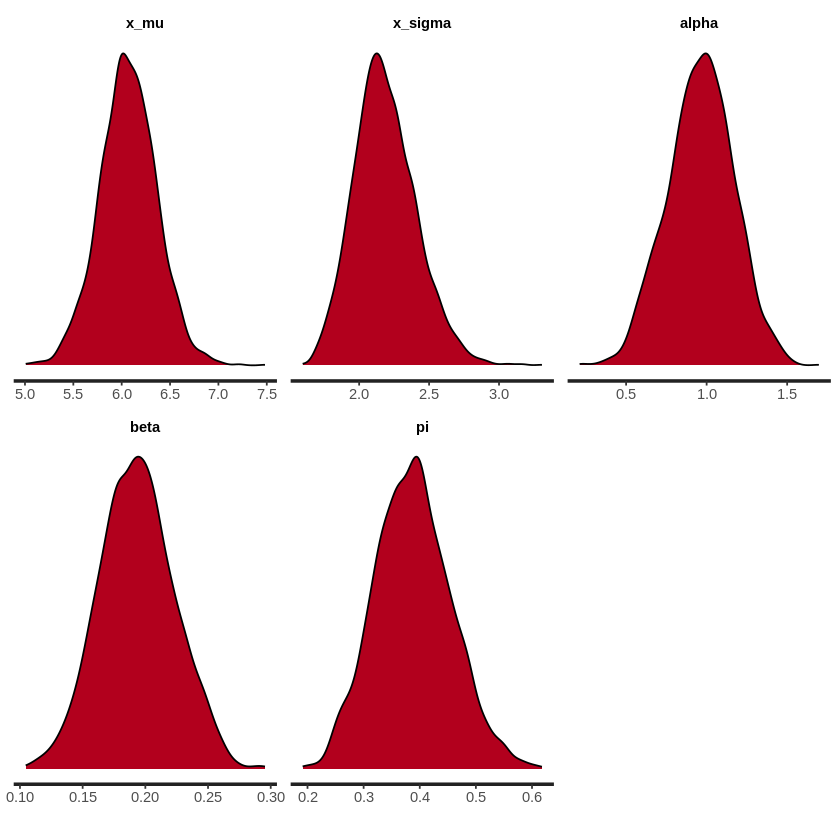

In [21]:
stan_dens(model_fit, pars = c('x_mu', 'x_sigma', 'alpha', 'beta', 'pi'))

Then we'll extract the posterior samples, and visualize the results.

In [22]:
posterior_samples <- rstan::extract(model_fit)

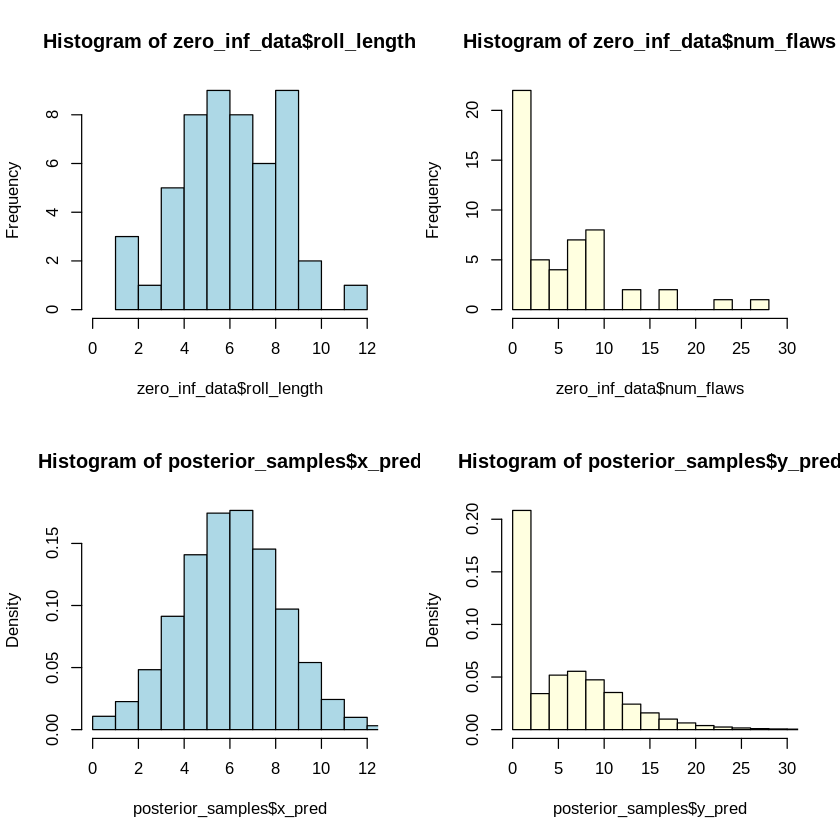

In [23]:
par(mfrow=c(2,2))
hist(zero_inf_data$roll_length, breaks=10, col="lightblue", xlim=c(0,12))
hist(zero_inf_data$num_flaws, breaks=12, col="lightyellow", xlim=c(0,30))
hist(posterior_samples$x_pred, breaks=15, col="lightblue", probability = TRUE, xlim=c(0,12))
hist(posterior_samples$y_pred, breaks=50, col="lightyellow", probability = TRUE, xlim=c(0,30))

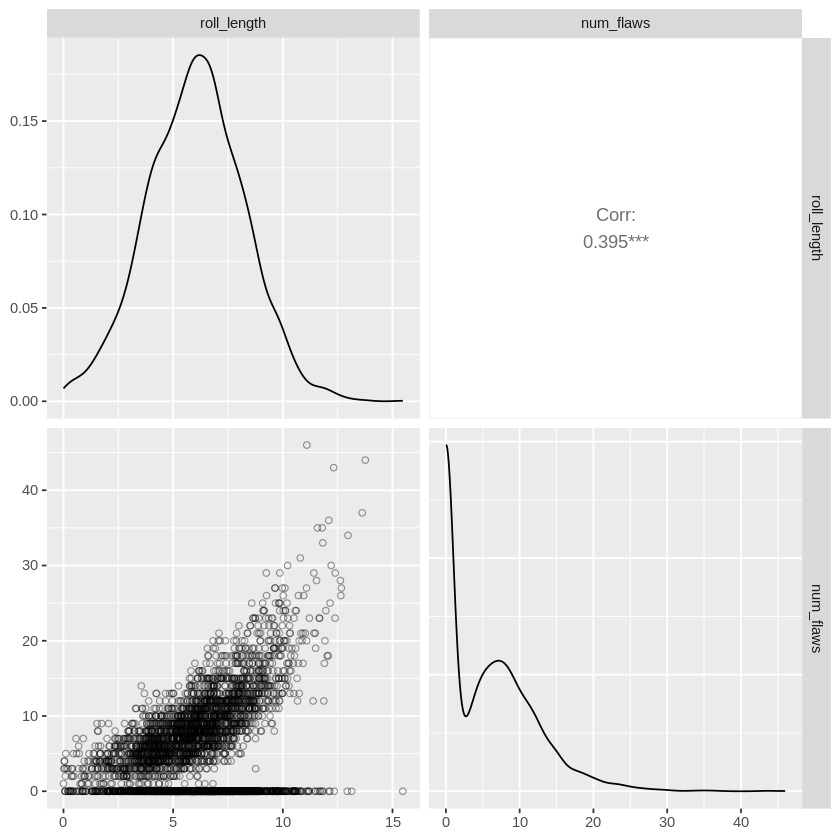

In [26]:
pred_df <- data.frame(roll_length = as.vector(posterior_samples$x_pred),
                      num_flaws = as.vector(posterior_samples$y_pred))
sampled_df <- pred_df[sample(1:nrow(pred_df), size = 4000), ]
ggpairs(sampled_df,
        lower = list(continuous = wrap("points", alpha = 0.4, shape = 1)),)

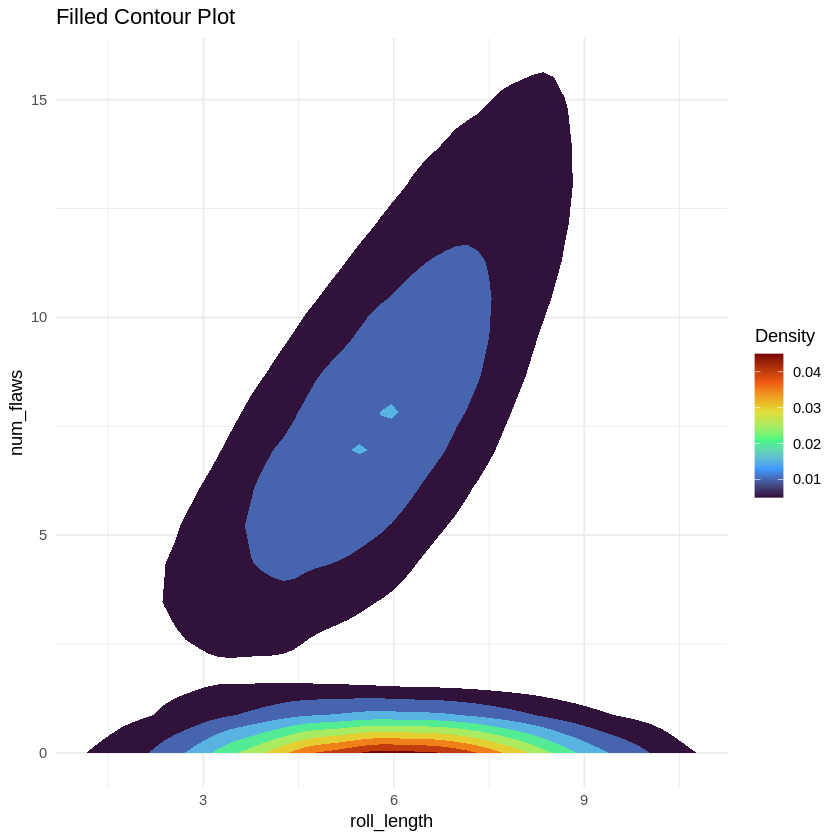

In [27]:
ggplot(pred_df, aes(x = roll_length, y = num_flaws)) +
  stat_density_2d(aes(fill = after_stat(level)), geom = "polygon") +
  scale_fill_viridis_c(option = "turbo") +
  theme_minimal() +
  labs(title = "Filled Contour Plot",
       x = "roll_length", y = "num_flaws", fill = "Density")

# Doing it With Priors

Now, we'll repeat the process, using priors on our model parameters. There are a variety of ways to choose priors, such as using weakly informative priors with wide variance, or allowing the data to inform their construction. Basing priors strongly upon the data is not quite the Bayesian way, but there is a notion of bootstrapped priors that I find interesting, and so I will arbitrarily choose this method for constructing our priors below.

Bootstrapping, if you're not familiar, refers to resampling our data with replacement in order to construct multiple data sets that likely resemble the original, but with variability. The insight we gain is what the data-generating process is likely to produce given multiple measurements. Throughout the process, we will collect lists of the parameters found, such as our mean and standard deviation for <code>roll_length</code>, and our intercept and slope parameters for the regression producing <code>num_flaws</code>.

## Bootstrapped Normal Priors for Roll Length

In [28]:
boot_normal <- function(data, indices) {
  sample_data <- data[indices]
  mean_val <- mean(sample_data)
  sd_val <- sd(sample_data)
  return(c(mean_val, sd_val))
}

In [29]:
bootstrap_results <- boot(data = data$roll_length, statistic = boot_normal, R = 1000)

boot_means <- bootstrap_results$t[,1]
boot_sds <- bootstrap_results$t[,2]

boot_mu_mean <- mean(boot_means)
boot_mu_sd <- sd(boot_means)

boot_sigma_mean <- mean(boot_sds)
boot_sigma_sd <- sd(boot_sds)

options(digits=3)
cat("Bootstrapped Prior Mean of Means:", boot_mu_mean, "\n")
cat("Bootstrapped Prior SD of Means:", boot_mu_sd, "\n")
cat("Bootstrapped Prior Mean of SDs:", boot_sigma_mean, "\n")
cat("Bootstrapped Prior SD of SDs:", boot_sigma_sd, "\n")

Bootstrapped Prior Mean of Means: 5.88 
Bootstrapped Prior SD of Means: 0.378 
Bootstrapped Prior Mean of SDs: 2.06 
Bootstrapped Prior SD of SDs: 0.23 


The distribution of the means and standard deviations for roll length look as follows:

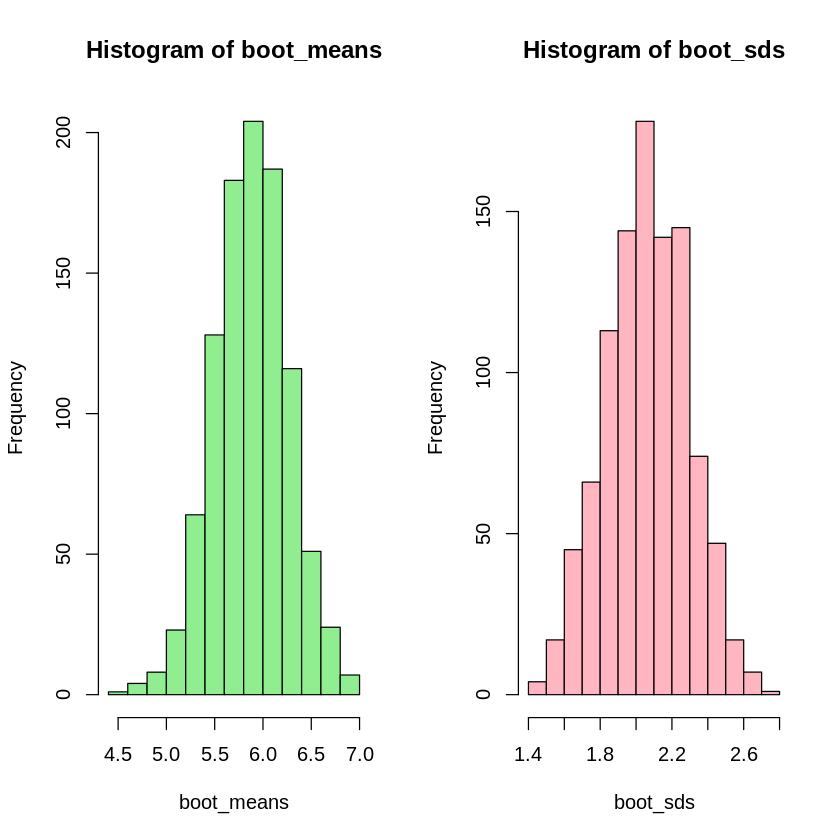

In [30]:
par(mfrow=c(1,2))
hist(boot_means, col="lightgreen")
hist(boot_sds, col="lightpink")

## Bootstrapped Intercept and Slope Priors for Num Flaws

The below function uses the (non-Bayesian) <code>glm</code> function of R to repeatedly fit a Poisson regression model. The computation speed is very fast, so we are easily able to resample 1000 times.

In [31]:
boot_pois_reg <- function(data, indices) {
  sample_data <- data[indices, ]
  fit <- glm(num_flaws ~ roll_length, data = sample_data, family = poisson())
  coef_mu <- coef(fit)
  return(coef_mu)
}

In [32]:
bootstrap_results <- boot(data = data, statistic = boot_pois_reg, R = 1000)

boot_intercepts <- bootstrap_results$t[,1]
boot_slopes <- bootstrap_results$t[,2]

boot_alpha_mean <- mean(boot_intercepts)
boot_alpha_sd <- sd(boot_intercepts)

boot_beta_mean <- mean(boot_slopes)
boot_beta_sd <- sd(boot_slopes)

options(digits=3)
cat("Bootstrapped Prior Mean of Intercept:", boot_alpha_mean, "\n")
cat("Bootstrapped Prior SD of Intercept:", boot_alpha_sd, "\n")
cat("Bootstrapped Prior Mean of Slope:", boot_beta_mean, "\n")
cat("Bootstrapped Prior SD of Slope:", boot_beta_sd, "\n")

Bootstrapped Prior Mean of Intercept: 0.947 
Bootstrapped Prior SD of Intercept: 0.344 
Bootstrapped Prior Mean of Slope: 0.195 
Bootstrapped Prior SD of Slope: 0.0548 


The distribution of the <code>alpha</code> and <code>beta</code> parameters look as follows:

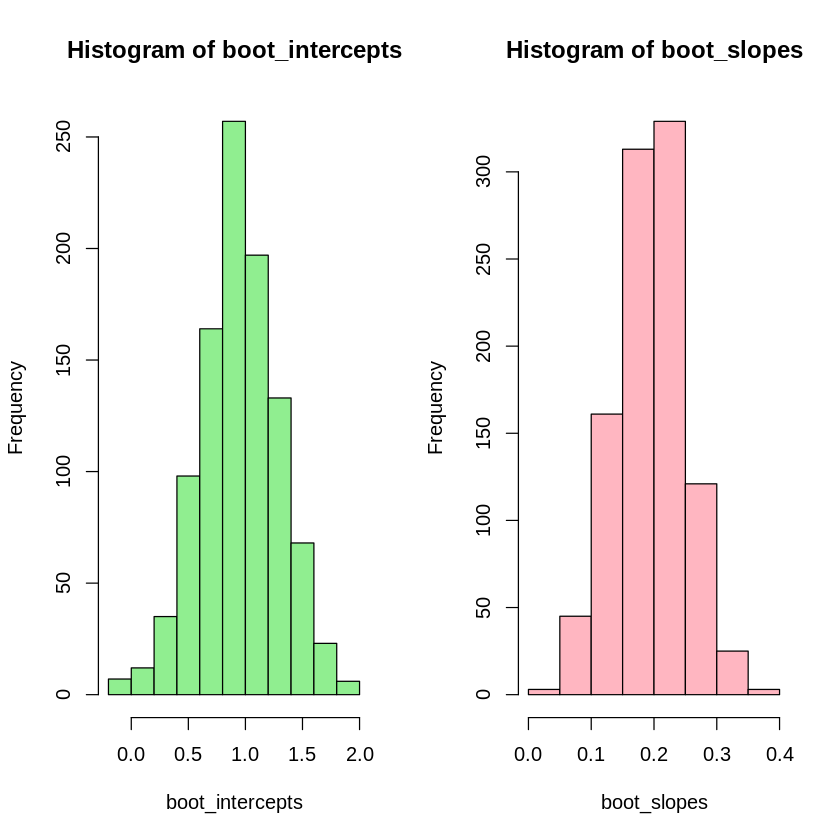

In [33]:
par(mfrow=c(1,2))
hist(boot_intercepts, col="lightgreen")
hist(boot_slopes, col="lightpink")

## Regular Poisson Regression with Priors

We create the following <code>stan</code> model, with several additions to the <code>data{}</code> block for us to pass in the priors, and you'll notice that the <code>model{}</code> block has several new statements, which associate the priors we passed in to the appropriate parameters.

In [55]:
stan_code <- "

  data {
      int<lower=0> N;
      vector[N] x;
      int<lower=0> y[N];
      real x_mu_mean, x_mu_sd;
      real x_sigma_mean, x_sigma_sd;
      real alpha_mean, alpha_sd;
      real beta_mean, beta_sd;
  }

  parameters {
      real x_mu, x_sigma;
      real alpha, beta;
  }

  model {
      vector[N] lambda;

      x_mu ~ normal(x_mu_mean, x_mu_sd);
      x_sigma ~ normal(x_sigma_mean, x_sigma_sd);

      alpha ~ normal(alpha_mean, alpha_sd);
      beta ~ normal(beta_mean, beta_sd);

      x ~ normal(x_mu, x_sigma);
      lambda = exp(alpha + beta * x);

      y ~ poisson(lambda);
  }

  generated quantities{
      vector[N] x_pred;
      vector[N] y_pred;

      for (n in 1:N) {
          x_pred[n] = fabs(normal_rng(x_mu, x_sigma));
          real lambda_pred = fabs(exp(x_pred[n] * beta + alpha));
          y_pred[n] = poisson_rng(lambda_pred);
      }
  }
  "

The following is lengthier than before, because we are passing each value for our priors in via the <code>data_list</code>.

In [56]:
x <- data$roll_length
y <- data$num_flaws

N <- length(x)
data_list <- list(N = N, x = x, y = y,
                  x_mu_mean = boot_mu_mean,
                  x_mu_sd = boot_mu_sd,
                  x_sigma_mean = boot_sigma_mean,
                  x_sigma_sd = boot_sigma_sd,
                  alpha_mean = boot_alpha_mean,
                  alpha_sd = boot_alpha_sd,
                  beta_mean = boot_beta_mean,
                  beta_sd = boot_beta_sd)
model_fit <- stan(model_code = stan_code, data = data_list, warmup = 1000,
                 iter = 2000, chains = 3, refresh = 0, cores = 8)

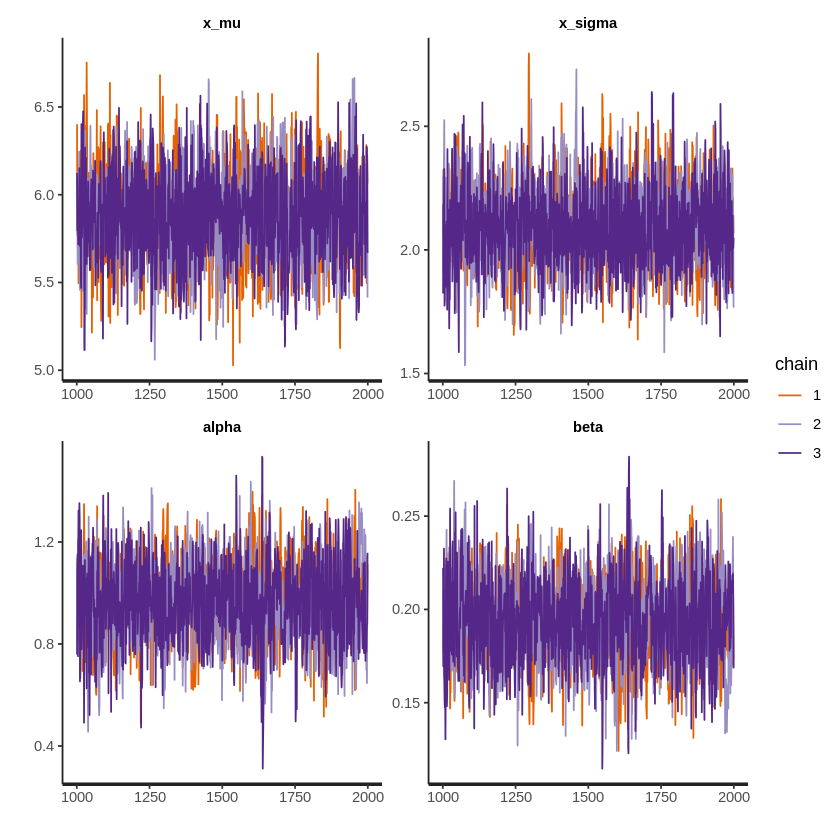

In [57]:
traceplot(model_fit, pars=c('x_mu', 'x_sigma', 'alpha', 'beta'))

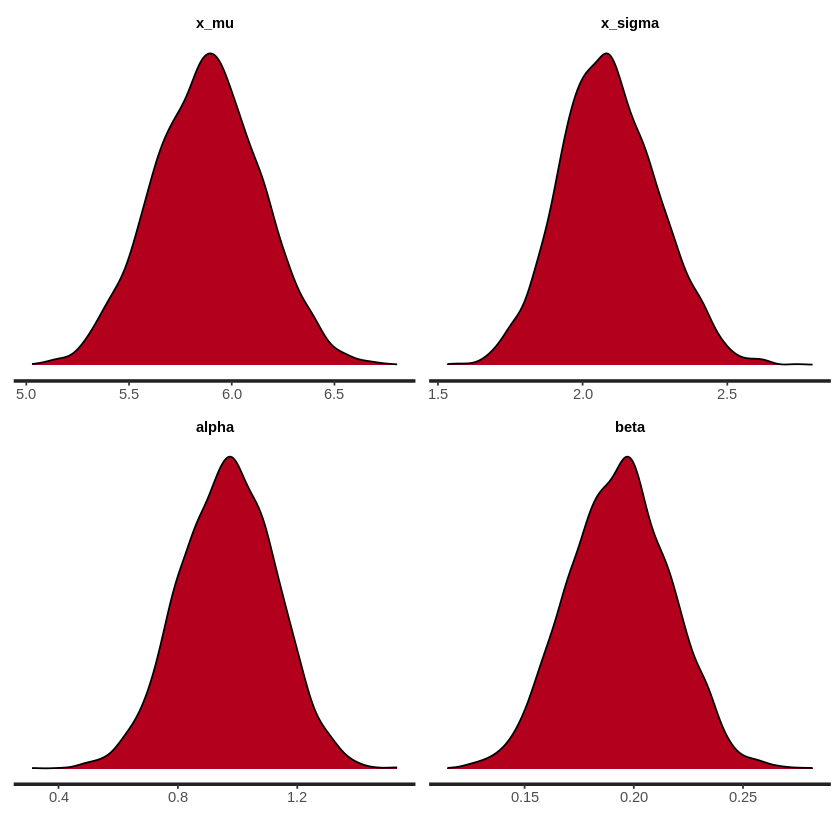

In [60]:
stan_dens(model_fit, pars=c('x_mu', 'x_sigma', 'alpha', 'beta'))

Then we can extract the samples...

In [36]:
posterior_samples <- rstan::extract(model_fit)

And visualize the results, which look very similar to what was found using flat priors (because we based our priors upon the data). Different methods would yield different results.

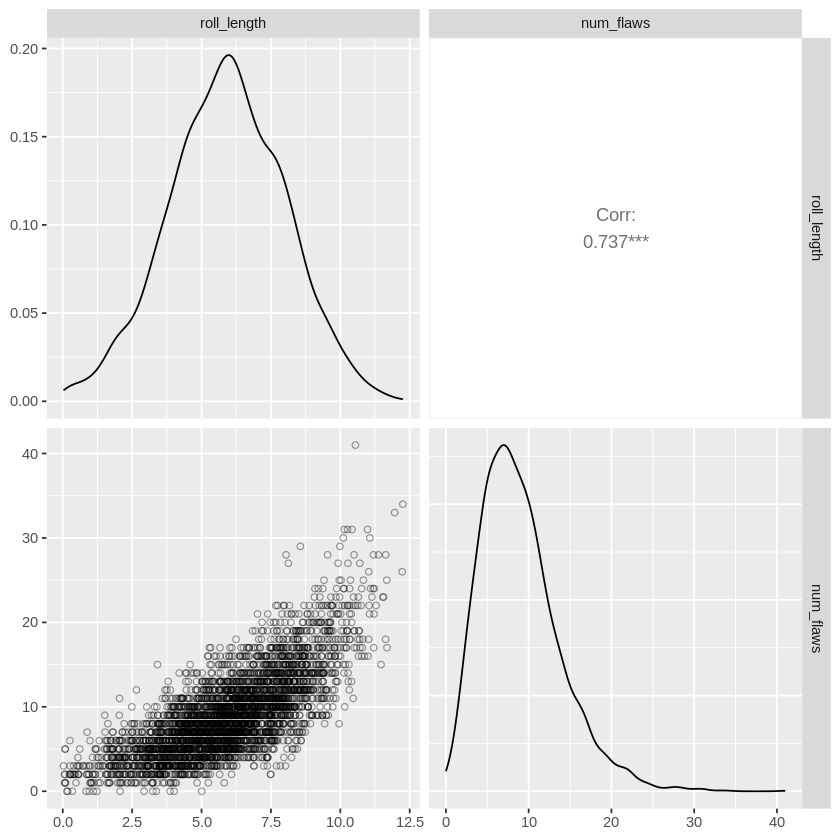

In [37]:
pred_df <- data.frame(roll_length = as.vector(posterior_samples$x_pred),
                      num_flaws = as.vector(posterior_samples$y_pred))
sampled_df <- pred_df[sample(1:nrow(pred_df), size = 4000), ]
ggpairs(sampled_df,
        lower = list(continuous = wrap("points", alpha = 0.4, shape = 1)),)

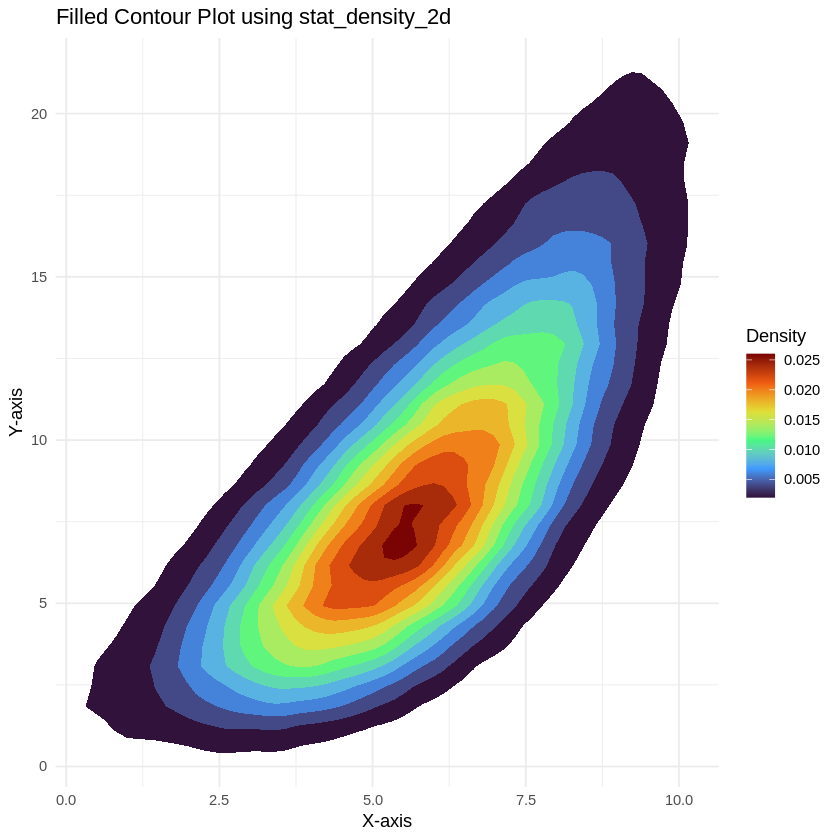

In [38]:
ggplot(pred_df, aes(x = roll_length, y = num_flaws)) +
  stat_density_2d(aes(fill = after_stat(level)), geom = "polygon") +
  scale_fill_viridis_c(option = "turbo") +
  theme_minimal() +
  labs(title = "Filled Contour Plot using stat_density_2d",
       x = "X-axis", y = "Y-axis", fill = "Density")

## Bootstrapping Zero-Inflated Regression Parameters

Now, let's repeat the process above, but with zero-inflated Poisson regression. This means defining a new function for bootstrapping, this time relying on the <code>zeroinf</code> function of the <code>pscl</code> library to perform the regression in a zero-inflated manner. This will return not just intercept and slope parameters, but values for <code>pi</code>, the zero-inflation parameter.

In [39]:
boot_zip_pi <- function(data, indices) {
  sample_data <- data[indices, ]
  zip_model <- zeroinfl(num_flaws ~ roll_length | 1, data = sample_data, dist = "poisson")
  alpha <- data.frame(coef(zip_model))[1,]
  beta <- data.frame(coef(zip_model))[2,]
  pi_logit <- data.frame(coef(zip_model))[3,]
  pi_prob <- 1 / (1 + exp(-pi_logit))
  return(c(alpha, beta, pi_prob))
}

In [40]:
boot_results <- boot(data = zero_inf_data, statistic = boot_zip_pi, R = 1000)
alphas <- boot_results$t[,1]
betas <- boot_results$t[,2]
pis <- boot_results$t[,3]

The parameters <code>alpha</code>, <code>beta</code>, and <code>pi</code> are distributed as follows:

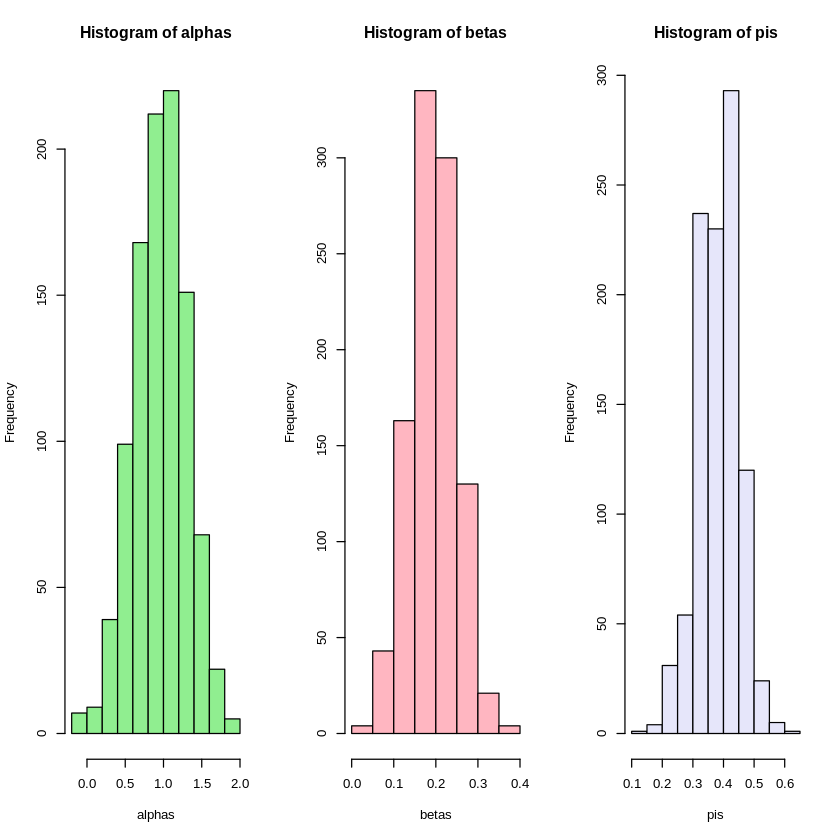

In [41]:
par(mfrow=c(1,3))

hist(alphas, col="lightgreen")
hist(betas, col="lightpink")
hist(pis, col="lavender")

## Zero-Inflated Poisson Regression with Priors

We'll use zero-inflated regression code that is similar to the previous iteration, but with additions to the <code>data{}</code> and <code>model{}</code> block similar to the regular Poisson regression with priors directly above.

In [42]:
stan_code <- "

data {
  int<lower=0> N;
  vector[N] x;
  int<lower=0> y[N];
  real x_mu_mean, x_mu_sd;
  real x_sigma_mean, x_sigma_sd;
  real alpha_mean, alpha_sd;
  real beta_mean, beta_sd;
  real pi_mean, pi_sd;
}

parameters {
  real x_mu, x_sigma;
  real alpha, beta;
  real<lower=0, upper=1> pi;
}

model {
  x_mu ~ normal(x_mu_mean, x_mu_sd);
  x_sigma ~ normal(x_sigma_mean, x_sigma_sd);
  x ~ normal(x_mu, x_sigma);
  pi ~ normal(pi_mean, pi_sd);
  alpha ~ normal(alpha_mean, alpha_sd);
  beta ~ normal(beta_mean, beta_sd);

  for (n in 1:N) {
    if (y[n] == 0) {
      target += log_mix(pi,
                        0,                                           // Log prob of y=0 in zero-inflated part
                        poisson_lpmf(0 | exp(alpha + beta * x[n]))); // Log-prob of y=0 in Poisson part
    } else {

      // set y given exp(alpha + beta * x[n]) ~ zip
      target += log1m(pi) + poisson_lpmf(y[n] | exp(alpha + beta * x[n]));
    }
  }
}

generated quantities {
  vector[N] x_pred;
  int y_pred[N];

  for (n in 1:N) {
    x_pred[n] = fabs(normal_rng(x_mu, x_sigma));
    real lambda_pred = exp(alpha + beta * x_pred[n]);

    if (bernoulli_rng(pi) == 1) {
      y_pred[n] = 0;                         // zero from zero-inflation
    } else {
      y_pred[n] = poisson_rng(lambda_pred);  // Poisson generated value
    }
  }
}
"

In [43]:
boot_alpha_mean <- mean(alphas)
boot_alpha_sd <- sd(alphas)
boot_beta_mean <- mean(betas)
boot_beta_sd <- sd(betas)
boot_pi_mean <- mean(pis)
boot_pi_sd <- sd(pis)

In [44]:
x <- data$roll_length
y <- data$num_flaws

N <- length(x)
data_list <- list(N = N, x = x, y = y,
                  x_mu_mean = boot_mu_mean,
                  x_mu_sd = boot_mu_sd,
                  x_sigma_mean = boot_sigma_mean,
                  x_sigma_sd = boot_sigma_sd,
                  alpha_mean = boot_alpha_mean,
                  alpha_sd = boot_alpha_sd,
                  beta_mean = boot_beta_mean,
                  beta_sd = boot_beta_sd,
                  pi_mean = boot_pi_mean,
                  pi_sd = boot_pi_sd)
model_fit <- stan(model_code = stan_code, data = data_list, warmup = 1000,
                 iter = 2000, chains = 3, refresh = 0, cores = 8)

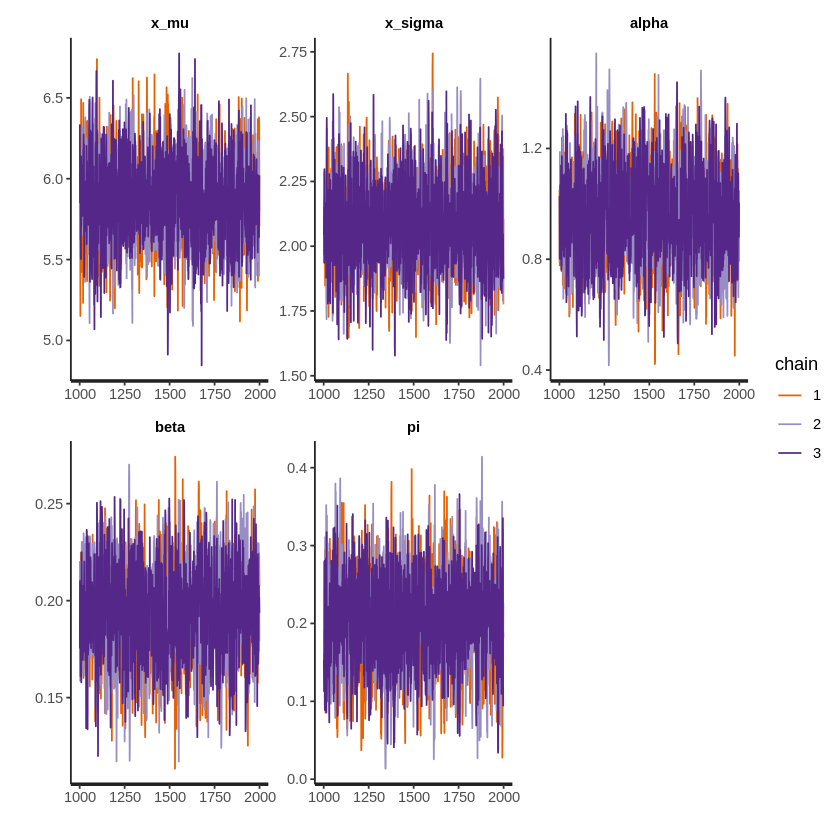

In [48]:
traceplot(model_fit, pars=c('x_mu', 'x_sigma', 'alpha', 'beta', 'pi'))

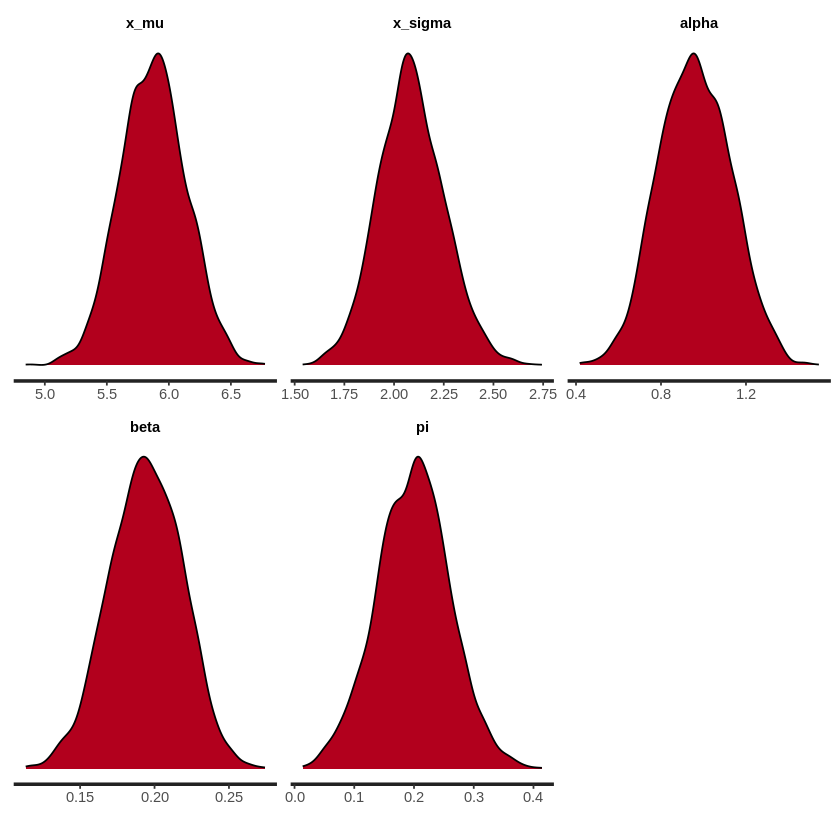

In [51]:
stan_dens(model_fit, pars=c('x_mu', 'x_sigma', 'alpha', 'beta', 'pi'))

Then we can extract the samples...

In [52]:
posterior_samples <- rstan::extract(model_fit)

And visualize the results. You can see from the contour plot that, even though our priors were based on the data, they did have an effect compared to that of the previous zero-inflated model.

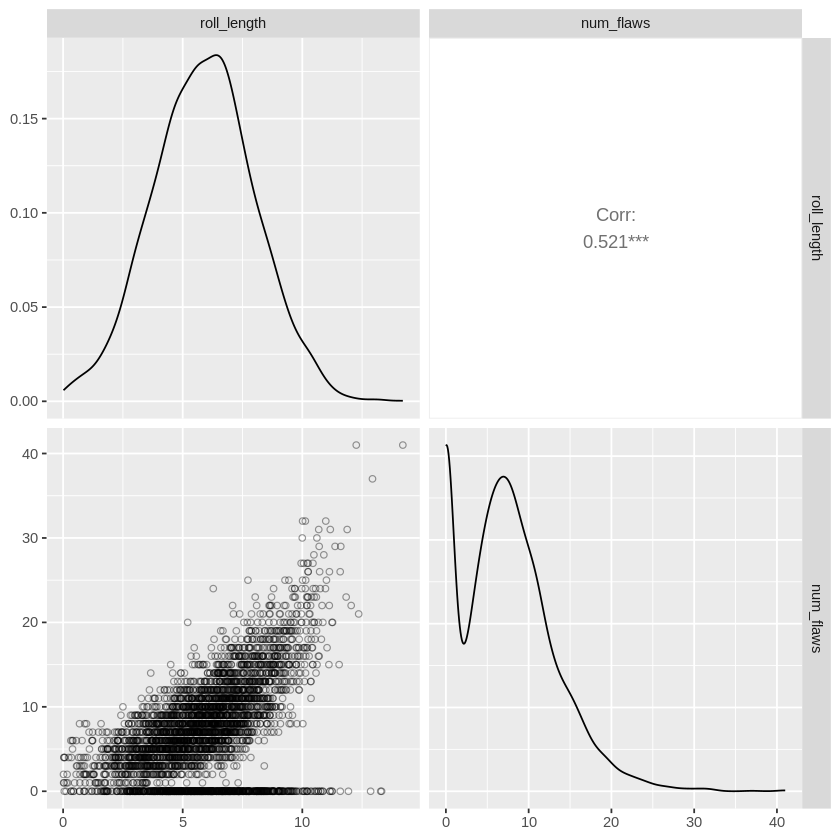

In [53]:
pred_df <- data.frame(roll_length = as.vector(posterior_samples$x_pred),
                      num_flaws = as.vector(posterior_samples$y_pred))
sampled_df <- pred_df[sample(1:nrow(pred_df), size = 4000), ]
ggpairs(sampled_df,
        lower = list(continuous = wrap("points", alpha = 0.4, shape = 1)),)

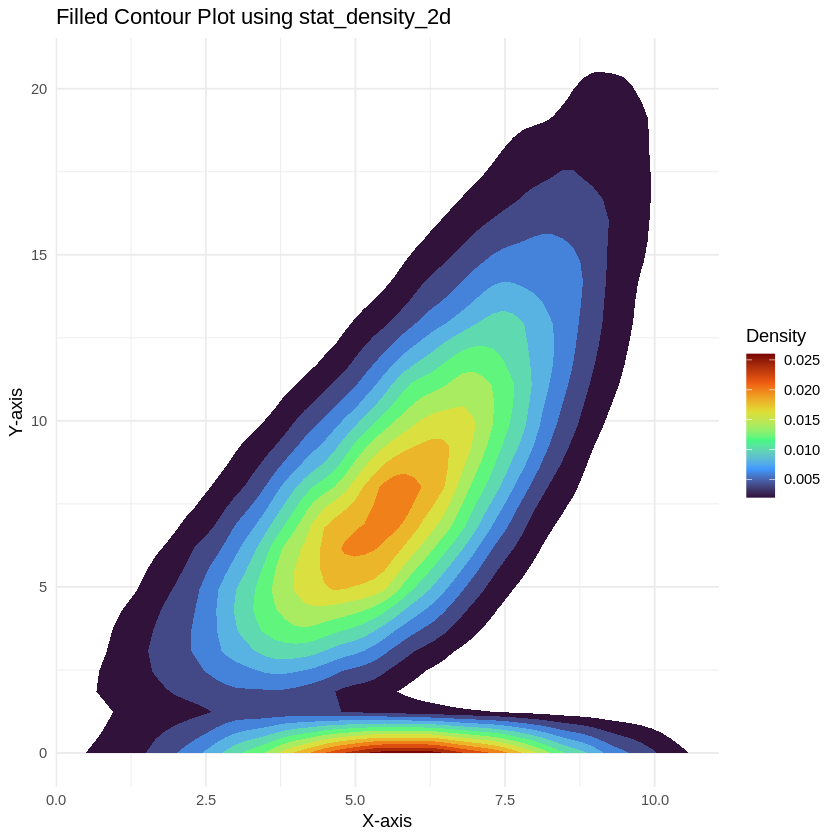

In [54]:
ggplot(pred_df, aes(x = roll_length, y = num_flaws)) +
  stat_density_2d(aes(fill = after_stat(level)), geom = "polygon") +
  scale_fill_viridis_c(option = "turbo") +
  theme_minimal() +
  labs(title = "Filled Contour Plot using stat_density_2d",
       x = "X-axis", y = "Y-axis", fill = "Density")

And with that, I'll conclude the article, which has demonstrated a method of regression appropriate for count outcomes. A constraint of working with the Poisson distribution is that mean and variance are assumed to be equal, and for count data with greater dispersion, we might select a negative binomial model instead, which also models count, but has an additional parameter. Doing this in <code>stan</code> is the subject of the next article, found <a href="https://nbviewer.org/github/pw598/Articles/blob/main/GLMs%20in%20RStan%20II%20-%20Negative%20Binomial%20and%20ZINB%20Regression.ipynb">here</a>. Following it is an article about Gamma regression, for positive real results which may exhibit a long tail.

# References

- Stan User Guide https://mc-stan.org/docs/stan-users-guide/index.html

- Bambi User Docs, Zero-Inflated Poisson Regression https://bambinos.github.io/bambi/notebooks/zero_inflated_regression.html